# 2 · track_step — 이력을 보고 지금을 잇는다

t-4..t-1 의 검출 결과를 주고 t 의 물체를 답하게 합니다. 물체는 이미 가진 id 를 그대로 써야 하고, 처음 보는 것에만 새 id 를 줍니다. 표준적인 tracking 정식화입니다.

이 노트북은 네 가지를 확인합니다 — **어떤 원시 데이터에서**, **어떤 코드를 거쳐**, **무엇이 입력으로 들어가고**, **빌드된 파일이 그 코드와 일치하는지**. GPU 는 필요 없습니다.

In [1]:
import os, sys, json, textwrap
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import pandas as pd

from datatools import paths

ITEMS = os.path.join(paths.COMMON_DIR, "instruct_items_tasks01_06.parquet")
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)
wrap = lambda s, i="   ": textwrap.fill(str(s), 94, initial_indent=i,
                                        subsequent_indent=i)
VARIANTS = ['track_step_azdeg', 'track_step_bbox']
print("variants:", VARIANTS)

variants: ['track_step_azdeg', 'track_step_bbox']


## 1. 어떤 원시 데이터에서 오는가

| 아카이브 | 주기 | 읽는 것 |
|---|---|---|
| `obstacle.offline` | 10 Hz | track_id 가 정체성의 근거 |
| `egomotion` | 10 Hz | 월드 좌표 변환 |
| `radar` | 20 / 12.7 Hz | 5초 창을 4 Hz 로 20스캔 |
| `camera intrinsics` | 클립당 1 | bbox 형식과 CoT 의 가려짐 계산 |

## 2. 어떤 코드를 거치는가

실행 순서입니다.

| 함수 | 하는 일 |
|---|---|
| `local_ids(boxes)` | track_id 를 첫 등장 순으로 1,2,3... 로 재번호. 원본 id 는 임의의 큰 수이고, 이 태스크가 묻는 것은 번호가 아니라 일관성입니다 |
| `step_frame(boxes, t, ids, camera, scan)` | 한 순간의 물체 + 카메라 방위각 + 가려짐 비율 + 레이더 측정 |
| `occluded_fraction(box, nearer)` | 앞선 물체들이 이 박스를 덮는 면적 비율 |
| `step_text(objects, form)` | 이력과 답을 같은 형식으로 |
| `step_reason(now, previous, form)` | CoT 근거 |

전부 `datatools/frame_objects.py` 와 `datatools/geometry.py` 에 있습니다.

In [2]:
import inspect
from datatools import frame_objects as F
for name in ['local_ids', 'step_frame', 'occluded_fraction', 'step_text', 'step_reason']:
    fn = getattr(F, name, None)
    if fn is None:
        from datatools import geometry as G
        fn = getattr(G, name, None)
    if fn is None or not callable(fn):
        print(f'{name}: (모듈 함수 아님)'); continue
    doc = (inspect.getdoc(fn) or '').split(chr(10))[0]
    print(f'{name:34s} {doc[:80]}')

local_ids                          Track ids renumbered 1, 2, 3... in order of first appearance in the clip.
step_frame                         The objects at one instant, with both representations attached.
occluded_fraction                  How much of an image box the boxes in front of it cover.
step_text                          One instant as text, in whichever representation the instruction asked
step_reason                        Why each object is where the answer says, sensor by sensor.


## 3. 입력으로 무엇이 들어가는가

**비전 5장 (1 fps) · 레이더 20스캔 (5초, 4 Hz) · ego 20샘플 · 이력 4프레임**

입력 창은 태스크마다 다릅니다. 로더의 `WINDOWS` 표가 그것을 정하고, 레이더는 항상 20스캔이라 창의 길이가 바뀌면 샘플링 속도가 따라 바뀝니다 — 인코더 입력 모양은 변하지 않습니다.

In [3]:
from training.instruct_data import WINDOWS, INSTANT_TASKS, WINDOW_TASKS
for v in VARIANTS:
    for name in (v, v + "_cot"):
        if name in WINDOWS:
            secs, hz, frames = WINDOWS[name]
            print(f"{name:26s} 창 {secs}초 · 레이더 {hz} Hz × 20스캔 · 비전 {frames}장")
        elif name in INSTANT_TASKS:
            print(f"{name:26s} 순간 — 비전 1장 · 레이더 20스캔/1초 · ego 1")
        else:
            print(f"{name:26s} 클립 전체 — 비전 20장 · 레이더 20스캔/20초")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


track_step_azdeg           창 5초 · 레이더 4 Hz × 20스캔 · 비전 5장
track_step_azdeg_cot       창 5초 · 레이더 4 Hz × 20스캔 · 비전 5장
track_step_bbox            창 5초 · 레이더 4 Hz × 20스캔 · 비전 5장
track_step_bbox_cot        창 5초 · 레이더 4 Hz × 20스캔 · 비전 5장


## 4. 예제 10건 — 원시 입력째로

`notebooks/example_data/` 에 테스크마다 10건이 들어 있습니다. **parquet 도 원본 아카이브도 필요 없습니다.**

| 경로 | 내용 |
|---|---|
| `gen_data/<task>.jsonl` | LLM 학습에 쓰이는 아이템 그대로 — instruction, ego, 정답, 근거 |
| `raw/<task>/NN/frames/` | 그 아이템에 실제로 들어가는 프레임 |
| `raw/<task>/NN/radar.npz` | 그 창의 레이더 반사점 (패딩 제거) |

평문 변형과 CoT 변형은 같은 아이템입니다 — CoT 정답의 `answer` 필드가 평문 정답과 글자 그대로 같아서, 한 건이 둘을 모두 보여줍니다.

In [4]:
import glob
EX = os.path.abspath(os.path.join(os.getcwd(), "..", "example_data"))
examples = {}
for v in VARIANTS:
    path = os.path.join(EX, "gen_data", v + ".jsonl")
    examples[v] = [json.loads(l) for l in open(path)] if os.path.exists(path) else []
    print(f"{v:26s} {len(examples[v]):>2}건")
rows = [{"id": r["id"], "clip": r["clip_id"][:8], "프레임": r["n_frames"],
         "레이더 점": r["radar_points"], "정답 길이": len(r["target"]),
         "근거 길이": len(r["rationale"])}
        for v in VARIANTS for r in examples[v]]
pd.DataFrame(rows)

track_step_azdeg           10건
track_step_bbox            10건


,id,clip,프레임,레이더 점,정답 길이,근거 길이
0,track_step_azdeg/00,a194ada9,5,18333,30,168
1,track_step_azdeg/01,3c3a1cf8,5,3764,255,789
2,track_step_azdeg/02,e0662bdd,5,5168,4,95
3,track_step_azdeg/03,a0b303e0,5,15525,4,95
4,track_step_azdeg/04,25513eee,5,5346,248,809
5,track_step_azdeg/05,9f35e571,5,2711,245,829
6,track_step_azdeg/06,d33ea0d0,5,4121,250,874
7,track_step_azdeg/07,52927853,5,9147,243,819
8,track_step_azdeg/08,2341d994,5,9511,236,731
9,track_step_azdeg/09,ef9497f8,5,4877,254,763


한 건을 통째로 봅니다. instruction 이 출력 형식을 고르고, 근거가 그 형식의 답으로 이어집니다.

In [5]:
pool = examples[VARIANTS[0]]
# 예제는 전방 레이더가 있는 클립에서만 뽑았다. 데이터 전체로는 177,891 클립 중
# 17,130건(9.6%)이 전방 레이더가 없고, 그 조건에서는 아래 그림이 빈 채로 나온다.
r = next((x for x in pool if x["radar_points"]), pool[0])
if not r["radar_points"]:
    print("!! 이 예제는 전방 레이더가 없는 클립입니다 (반사점 0개)")
print("=" * 96)
print(f"{r['id']}   clip {r['clip_id'][:8]}   {r['sensors']}")
print(f"창: {r['window']}")
print()
print("instruction:"); print(wrap(r["instruction"].replace(chr(10), " | ")))
print("ego:");         print(wrap(r["ego"]))
print("answer (GT):"); print(wrap(r["target"]))
print("rationale:");   print(wrap(r["rationale"]))

track_step_azdeg/00   clip a194ada9   Sensors present: camera, ego motion, imaging long-range radar.
창: {'kind': 'window', 'seconds': 5, 'radar_hz': 4, 'video_frames': 5}

instruction:
   At frame 20. Previous detections: | t-4s: none | t-3s: none | t-2s: none | t-1s: #26
   automobile 180 m az +1 deg | Continue tracking: list the road users at this instant with
   its class, range and azimuth, reusing the id each object already has and giving a new id to
   anything not seen before.
ego:
   Ego motion (binned, 5 s at 4 Hz, ending at t=19s): t0:s19a16y15 t1:s19a16y15 t2:s19a15y16
   t3:s19a15y15 t4:s19a17y15 t5:s19a17y16 t6:s19a15y16 t7:s19a17y16 t8:s19a15y16 t9:s19a15y16
   t10:s19a17y16 t11:s19a15y16 t12:s19a17y16 t13:s19a16y16 t14:s19a18y16 t15:s19a17y16
   t16:s19a16y16 t17:s19a16y16 t18:s19a16y16 t19:s19a17y16
answer (GT):
   #26 automobile 134 m az +1 deg
rationale:
   #26 automobile: was at 180 m az +1 deg, camera az +2 deg, no radar return. Range comes from
   the radar where i

그 아이템에 실제로 들어가는 프레임과 레이더 반사점입니다. 레이더는 자차 기준 좌표(x 전방, y 좌)이고 색이 시선속도 — 정지 물체는 자차 속도의 음수로 모여 보입니다.

프레임 5장 · 반사점 18333개 · 채널 ['x', 'y', 'z', 'radial_velocity', 'doppler_residual', 'rcs', 'snr', 'range']


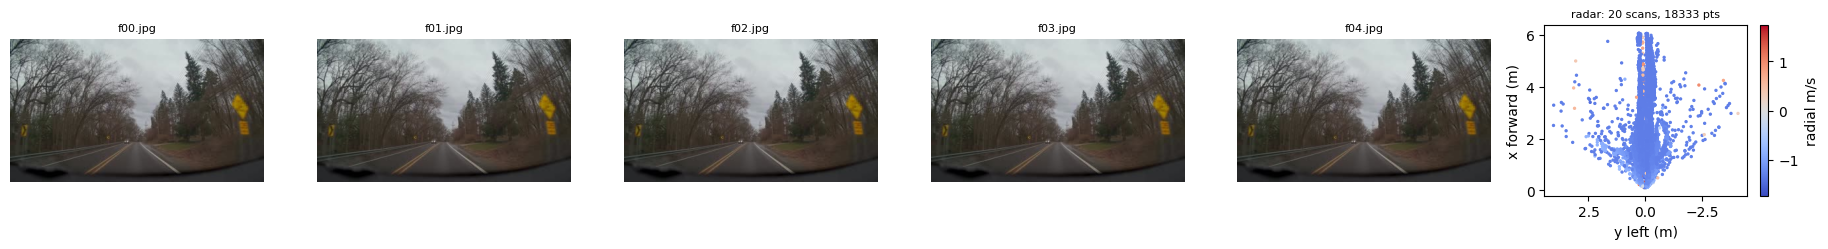

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

d = os.path.join(EX, r["raw"])
paths = sorted(glob.glob(os.path.join(d, "frames", "*.jpg")))
z = np.load(os.path.join(d, "radar.npz"))
pts, ch = z["points"].astype(np.float32), [str(c) for c in z["channels"]]
print(f"프레임 {len(paths)}장 · 반사점 {len(pts)}개 · 채널 {ch}")

fig, axes = plt.subplots(1, len(paths) + 1, figsize=(3.1 * (len(paths) + 1), 2.6))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p)); ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis("off")
ax = axes[-1]
# 그림 안 글자는 ASCII 로 둔다. matplotlib 의 기본 폰트에 한글 글리프가 없어
# 라벨이 네모로 나오고, 폰트 등록을 요구하면 노트북이 기계를 가린다.
if len(pts):
    s = ax.scatter(pts[:, ch.index("y")], pts[:, ch.index("x")], s=2,
                   c=pts[:, ch.index("radial_velocity")], cmap="coolwarm")
    ax.set_title(f"radar: {r['radar_scans']} scans, {len(pts)} pts", fontsize=8)
    ax.invert_xaxis(); fig.colorbar(s, ax=ax, label="radial m/s")
else:
    ax.text(0.5, 0.5, "no returns", ha="center", va="center")
    ax.set_title("clip has no forward radar", fontsize=8)
ax.set_xlabel("y left (m)"); ax.set_ylabel("x forward (m)")
plt.tight_layout(); plt.show()

## 5. 빌드된 파일의 실제 아이템

여기서부터는 parquet 이 있는 기계에서만 돕니다. 위의 예제가 빌드 전체와 같은 규칙으로 만들어졌는지 확인하는 절입니다.

In [7]:
built = pd.read_parquet(ITEMS)
for v in VARIANTS:
    sub = built[built.task == v]
    if sub.empty:
        print(f"{v}: 파일에 없음"); continue
    r = sub.iloc[0]
    print("=" * 96)
    print(f"{v}   clip {r.clip_id[:8]}  frame {r.frame} (t={r.frame-1}s)  split {r.split}")
    print("Q:"); print(wrap(r.prompt))
    print("A:"); print(wrap(r.target))

track_step_azdeg   clip 1f47bf7f  frame 6 (t=5s)  split train
Q:
   Previous detections: t-4s: #29 automobile 12 m az -52 deg; #27 automobile 13 m az +10 deg;
   #28 automobile 30 m az -23 deg; #34 automobile 30 m az -57 deg; #37 automobile 59 m az -60
   deg; #30 automobile 72 m az -47 deg; #31 automobile 81 m az -58 deg; #47 automobile 159 m
   az -58 deg t-3s: #27 automobile 8 m az +49 deg; #29 automobile 9 m az -45 deg; #35
   automobile 19 m az -59 deg; #28 automobile 24 m az +4 deg; #34 automobile 27 m az -39 deg;
   #33 automobile 33 m az -49 deg; #51 automobile 36 m az -47 deg; #54 automobile 46 m az -47
   deg t-2s: #29 automobile 5 m az -57 deg; #35 automobile 16 m az -53 deg; #28 automobile 18
   m az +31 deg; #34 automobile 21 m az -23 deg; #33 automobile 28 m az -33 deg; #51
   automobile 31 m az -31 deg; #54 automobile 41 m az -28 deg; #37 automobile 50 m az -17 deg
   t-1s: #28 automobile 14 m az +57 deg; #34 automobile 14 m az -20 deg; #33 automobile 22 m
   az -31 deg;

track_step_bbox   clip 1f47bf7f  frame 6 (t=5s)  split train
Q:
   Previous detections: t-4s: #29 automobile [932, 493, 999, 672]; #27 automobile [310, 499,
   512, 635]; #28 automobile [666, 472, 747, 531]; #34 automobile [980, 492, 999, 555]; #37
   automobile [996, 500, 999, 530]; #30 automobile [885, 498, 916, 519]; #31 automobile [983,
   506, 994, 526]; #47 automobile [979, 508, 987, 518] t-3s: #27 automobile [135, 488, 172,
   694]; #29 automobile [867, 497, 999, 768]; #35 automobile [961, 472, 999, 582]; #28
   automobile [418, 465, 521, 538]; #34 automobile [825, 500, 869, 567]; #33 automobile [894,
   490, 967, 549]; #51 automobile [882, 503, 943, 549]; #54 automobile [879, 499, 929, 537]
   t-2s: #29 automobile [896, 496, 999, 769]; #35 automobile [904, 467, 999, 604]; #28
   automobile [154, 457, 283, 563]; #34 automobile [678, 499, 745, 582]; #33 automobile [754,
   485, 842, 550]; #51 automobile [736, 501, 809, 550]; #54 automobile [720, 496, 777, 535];
   #37 automobile 

## 6. CoT — 근거가 답을 만드는가

`_cot` 변형은 `{"rationale": ..., "answer": ...}` 입니다. **근거를 따라가면 답이 나와야** 합니다. 나오지 않으면 그 사슬은 잘못된 것이고, 보상을 걸면 모델이 그 잘못된 사슬을 배웁니다.

In [8]:
for v in VARIANTS:
    name = v + "_cot"
    sub = built[built.task == name] if 'built' in dir() else None
    if sub is None or sub.empty:
        continue
    r = sub.iloc[0]
    d = json.loads(r.target)
    print("=" * 96); print(name)
    print("R:"); print(wrap(d["rationale"]))
    print("A:"); print(wrap(d["answer"]))

track_step_azdeg_cot
R:
   #34 automobile: was at 14 m az -20 deg, camera az -46 deg, radar 9 returns at 8 m az -32
   deg; #33 automobile: was at 22 m az -31 deg, camera az -49 deg, 84% occluded, no radar
   return; #51 automobile: was at 25 m az -28 deg, camera az -40 deg, 100% occluded, radar 3
   returns at 17 m az -31 deg; #54 automobile: was at 35 m az -22 deg, camera az -28 deg,
   radar 2 returns at 26 m az -23 deg; #37 automobile: was at 43 m az -7 deg, camera az -7
   deg, radar 4 returns at 34 m az -6 deg; #30 automobile: was at 54 m az +12 deg, camera az
   +16 deg, radar 3 returns at 47 m az +15 deg; #57 automobile: was at 57 m az -13 deg, camera
   az -14 deg, radar 2 returns at 49 m az -12 deg; #31 automobile: newly seen, camera az -4
   deg, radar 5 returns at 56 m az -4 deg. Range comes from the radar where it has a return
   and from the camera alone where it does not.
A:
   #34 automobile 7 m az -40 deg; #33 automobile 15 m az -45 deg; #51 automobile 17 m az -37
   d

track_step_bbox_cot
R:
   #34 automobile: was at 14 m az -20 deg, camera az -46 deg, radar 9 returns at 8 m az -32
   deg; #33 automobile: was at 22 m az -31 deg, camera az -49 deg, 84% occluded, no radar
   return; #51 automobile: was at 25 m az -28 deg, camera az -40 deg, 100% occluded, radar 3
   returns at 17 m az -31 deg; #54 automobile: was at 35 m az -22 deg, camera az -28 deg,
   radar 2 returns at 26 m az -23 deg; #37 automobile: was at 43 m az -7 deg, camera az -7
   deg, radar 4 returns at 34 m az -6 deg; #30 automobile: was at 54 m az +12 deg, camera az
   +16 deg, radar 3 returns at 47 m az +15 deg; #57 automobile: was at 57 m az -13 deg, camera
   az -14 deg, radar 2 returns at 49 m az -12 deg; #31 automobile: newly seen, camera az -4
   deg, radar 5 returns at 56 m az -4 deg. Range comes from the radar where it has a return
   and from the camera alone where it does not.
A:
   #34 automobile [758, 479, 999, 907]; #33 automobile [834, 456, 981, 603]; #51 automobile
   [77

## 7. 보상

평가 채점기에서 유도했습니다. 정답을 그대로 넣으면 1.0 이 나와야 하고, 내용을 망가뜨리면 떨어져야 합니다.

In [9]:
import re
from training.task_scorers import reward_for

def wreck(text):
    """형식은 두고 숫자만 2배로."""
    return re.sub(r"\d+(?:\.\d+)?",
                  lambda m: str(round(float(m.group()) * 2, 1)), text)

rows = []
for v in VARIANTS:
    for name in (v, v + "_cot"):
        fn = reward_for(name)
        if fn is None:
            continue
        sub = built[built.task == name] if 'built' in dir() else None
        if sub is None or sub.empty:
            continue
        t = sub.iloc[0].target
        rows.append({"task": name, "reward": fn.__name__,
                     "정답": round(fn(t, t), 3),
                     "숫자 2배": round(fn(wreck(t), t), 3)})
pd.DataFrame(rows)

,task,reward,정답,숫자 2배
0,track_step_azdeg,reward_tracking,1.0,0.00
1,track_step_azdeg_cot,reward_with_rationale[track_step_azdeg],1.0,0.15
2,track_step_bbox,reward_tracking,1.0,0.00
3,track_step_bbox_cot,reward_with_rationale[track_step_bbox],1.0,0.15


## 8. 데이터 양

`val` 은 `train` 에 합쳐져 있습니다 — 클립 분할이 train 86,607 / val 54,163 / test 37,121 인데, 모델 선택은 `test` 에서 하므로 검증용 3분의 1이 쓰이지 않고 있었습니다.

In [10]:
from collections import Counter
from training.instruct_data import load_items
names = [v for v in VARIANTS] + [v + "_cot" for v in VARIANTS]
rows = []
for split in ("train", "test"):
    c = Counter(i["task"] for i in load_items(tuple(names), split))
    for n in names:
        rows.append({"task": n, "split": split, "items": c.get(n, 0)})
pd.DataFrame(rows).pivot(index="task", columns="split", values="items")

split,test,train
task,,
track_step_azdeg,463740,1888095
track_step_azdeg_cot,463740,1888095
track_step_bbox,426426,1734833
track_step_bbox_cot,426426,1734833


## 9. 이 태스크에서 내린 결정과 근거

**앵커가 1초 간격인 이유**

롤아웃에서 이력은 자기 출력이므로 앵커 간격이 곧 이력 간격이 됩니다. 3초 간격 앵커에 1초 간격 이력을 쓰면 학습과 평가의 프롬프트가 달라집니다.

**id 는 값이 아니라 일관성으로 채점**

첫 차를 #2 라 불러도 계속 #2 이면 맞습니다. 항목 단위로는 프롬프트의 이력이 정한 id 를 이어받았는지 보고, 시퀀스 단위로는 IDF1 로 대응을 한 번 풀어 셉니다.

**가려짐이 76% 항목에 등장**

물체의 25.6% 가 이미지에서 절반 이상 가려지고, 그중 48.2% 는 레이더가 여전히 봅니다. 융합이 값을 하는 지점입니다.